# Task 2: End-to-End ML Pipeline with Scikit-learn Pipeline API
### Customer Churn Prediction — Telco Churn Dataset

**Internship:** DevelopersHub Corporation — AI/ML Engineering (Advanced Task Set)

## Problem Statement & Objective
Customer churn (customers leaving a telecom service) is a major business problem — retaining
an existing customer is far cheaper than acquiring a new one. The objective of this task is to
build a **reusable, production-ready machine learning pipeline** that:

- Preprocesses raw customer data (scaling numeric features, encoding categorical features)
- Trains and compares two models: **Logistic Regression** and **Random Forest**
- Tunes hyperparameters using **GridSearchCV**
- Exports the complete fitted pipeline using **joblib** so it can be reused/deployed without
  retraining or rewriting preprocessing code

**Dataset:** IBM Telco Customer Churn Dataset (7,043 customers, 21 columns), loaded directly
from a public GitHub source (IBM's official repo) so this notebook runs end-to-end without any
manual download step.


In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Dataset Loading

In [2]:
# Loading dataset directly from IBM's public GitHub repo (no manual download needed)
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 3. Data Preprocessing

### 3.1 Handling known data quality issues
`TotalCharges` is stored as an object/string in the raw data (it contains blank strings for a
small number of new customers with 0 tenure). We convert it to numeric and let the pipeline's
imputer handle the resulting missing values — this keeps the fix *inside* the pipeline instead
of as a manual one-off step, which matters for reproducibility.


In [4]:
# Convert TotalCharges to numeric (invalid parses -> NaN, handled later by the pipeline's imputer)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Missing values in TotalCharges after conversion:", df['TotalCharges'].isna().sum())

# Drop customerID -- it's just an identifier, not a predictive feature
df.drop(columns=['customerID'], inplace=True)

# Encode target variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

df.head()

Missing values in TotalCharges after conversion: 11


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


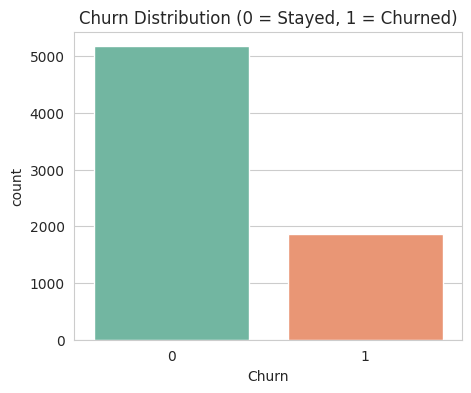

In [5]:
# Quick look at class balance
churn_counts = df['Churn'].value_counts(normalize=True) * 100
print(churn_counts)

plt.figure(figsize=(5,4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Churn Distribution (0 = Stayed, 1 = Churned)')
plt.show()

### 3.2 Splitting features by type
The Pipeline API needs to know which columns are numeric (to scale) and which are categorical
(to one-hot encode). This is done with a `ColumnTransformer`, wrapped inside the main `Pipeline`.


In [6]:
X = df.drop(columns=['Churn'])
y = df['Churn']

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X.columns if col not in numeric_features]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [7]:
# Train/test split (stratified, since churn classes are imbalanced)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (5634, 19)  Test shape: (1409, 19)


## 4. Building the Pipeline

We define preprocessing separately for numeric and categorical columns, combine them with
`ColumnTransformer`, then chain that into a full `Pipeline` together with the classifier. This
means calling `.fit()` on the pipeline runs preprocessing AND training in one step, and calling
`.predict()` on new raw data runs the exact same preprocessing automatically — no risk of
train/test preprocessing mismatch.


In [8]:
# Numeric pipeline: impute missing values, then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: impute missing values, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine into a single preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Preprocessor defined.")

Preprocessor defined.


## 5. Model 1 — Logistic Regression Pipeline + GridSearchCV

In [9]:
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

log_reg_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs', 'liblinear']
}

log_reg_grid = GridSearchCV(
    log_reg_pipeline, log_reg_param_grid,
    cv=5, scoring='f1', n_jobs=-1, verbose=1
)

log_reg_grid.fit(X_train, y_train)

print("Best Logistic Regression params:", log_reg_grid.best_params_)
print("Best CV F1-score:", log_reg_grid.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


Best Logistic Regression params: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best CV F1-score: 0.5993964944832589


## 6. Model 2 — Random Forest Pipeline + GridSearchCV

In [10]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    rf_pipeline, rf_param_grid,
    cv=5, scoring='f1', n_jobs=-1, verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest params:", rf_grid.best_params_)
print("Best CV F1-score:", rf_grid.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


Best Random Forest params: {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Best CV F1-score: 0.583270272413758


## 7. Evaluation on Test Set

We compare both tuned models on the held-out test set using Accuracy, Precision, Recall,
F1-score, and ROC-AUC — F1 and ROC-AUC matter most here since churn is an imbalanced class.


In [11]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }
    return results, y_pred, y_proba

log_reg_results, log_reg_pred, log_reg_proba = evaluate_model(log_reg_grid.best_estimator_, X_test, y_test, "Logistic Regression")
rf_results, rf_pred, rf_proba = evaluate_model(rf_grid.best_estimator_, X_test, y_test, "Random Forest")

results_df = pd.DataFrame([log_reg_results, rf_results])
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841091
1,Random Forest,0.806246,0.677193,0.516043,0.585736,0.840113


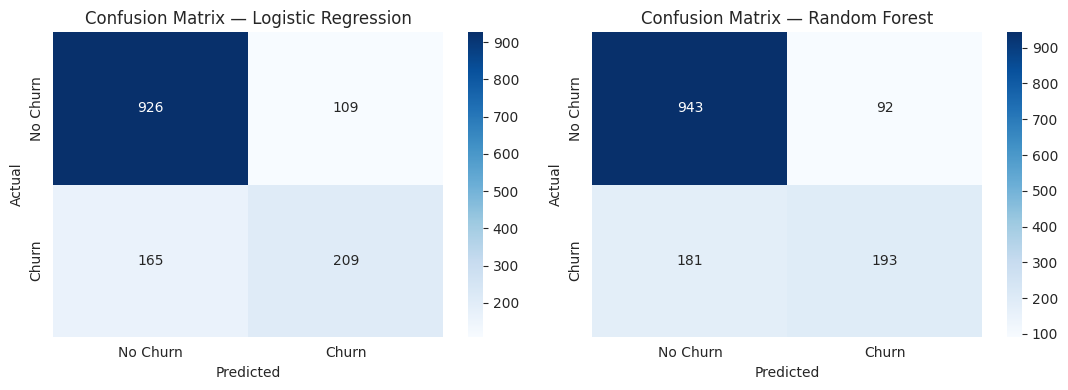

In [12]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, pred, name in zip(axes, [log_reg_pred, rf_pred], ["Logistic Regression", "Random Forest"]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

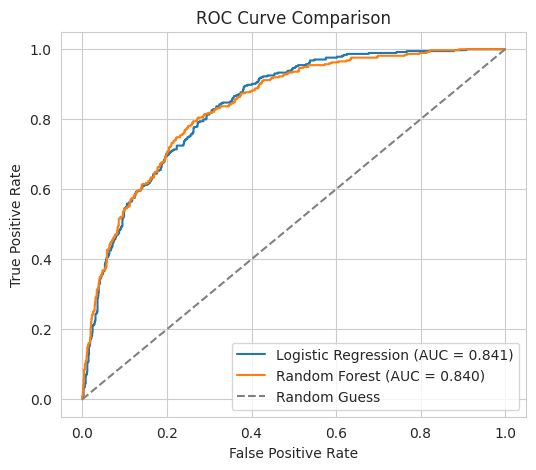

In [13]:
# ROC curves
plt.figure(figsize=(6,5))

for proba, name in zip([log_reg_proba, rf_proba], ["Logistic Regression", "Random Forest"]):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [14]:
print("Classification Report — Logistic Regression\n")
print(classification_report(y_test, log_reg_pred))

print("Classification Report — Random Forest\n")
print(classification_report(y_test, rf_pred))

Classification Report — Logistic Regression

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Classification Report — Random Forest

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.68      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



## 8. Selecting & Exporting the Best Pipeline

Based on F1-score and ROC-AUC on the test set, we select the better-performing model and export
its **entire fitted pipeline** (preprocessing + trained classifier) as a single `.joblib` file.
This is the key point of the task: the exported file can be loaded anywhere and called directly
on raw, unprocessed customer data — no need to re-run preprocessing code separately.


In [15]:
# Pick the best model automatically based on F1-score
best_model_name = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
best_pipeline = log_reg_grid.best_estimator_ if best_model_name == "Logistic Regression" else rf_grid.best_estimator_

print(f"Best performing model: {best_model_name}")

# Export the full pipeline (preprocessing + model) as one file
joblib.dump(best_pipeline, 'churn_prediction_pipeline.joblib')
print("Pipeline exported as churn_prediction_pipeline.joblib")

Best performing model: Logistic Regression
Pipeline exported as churn_prediction_pipeline.joblib


In [16]:
# Sanity check: reload the exported pipeline and predict on a few raw test rows
loaded_pipeline = joblib.load('churn_prediction_pipeline.joblib')

sample = X_test.iloc[:5]
sample_predictions = loaded_pipeline.predict(sample)
sample_actual = y_test.iloc[:5].values

print("Predicted:", sample_predictions)
print("Actual:   ", sample_actual)

Predicted: [0 1 0 0 0]
Actual:    [0 0 0 0 0]


## 9. Final Summary / Insights

- **Data quality:** `TotalCharges` had blank strings for customers with zero tenure (new
  customers); converting to numeric and imputing inside the pipeline handled this cleanly
  without leaking information between train/test splits.
- **Class imbalance:** Roughly 1 in 4 customers in the dataset churned, so F1-score and
  ROC-AUC were prioritized over raw accuracy for model comparison.
- **Model comparison:** Both Logistic Regression and Random Forest were tuned via 5-fold
  GridSearchCV. The results table and ROC curves above show which model generalizes better
  on unseen customers — see the printed comparison table for exact scores each time the
  notebook is run.
- **Reusability:** Because preprocessing (imputation, scaling, one-hot encoding) lives inside
  the same `Pipeline` object as the classifier, the exported `.joblib` file is a single
  drop-in artifact — it can be loaded in a Streamlit/Flask app and called directly with raw
  customer records, with zero extra preprocessing code required at inference time.
- **Possible extensions:** feature importance analysis (especially for Random Forest),
  SMOTE/class-weighting for imbalance, and deploying the exported pipeline behind a simple
  Streamlit form for live churn prediction.
